In [1]:
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **Explotary Data analysis (EDA)**

In [2]:
files = glob("../data/buenos-aires-real-estate*.csv")
files

['../data/buenos-aires-real-estate.csv']

In [3]:
df = pd.read_csv(files[0])
df.head()

/tmp/ipykernel_498/185955425.py:1: DtypeWarning: Columns (0: expenses) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(files[0])


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,,http://chacarita.properati.com.ar/10qlv_venta_...


In [4]:
df.shape

(43029, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

In [6]:
df["property_type"].value_counts()

property_type
apartment    23228
house        15723
PH            2855
store         1223
Name: count, dtype: int64

In [7]:
# only care about apartments, and only Capital Federal (city proper, not greater BA)
df["place_with_parent_names"].str.contains("Capital Federal").sum()

np.int64(12491)

# **Checking for skewness of Numeric Data**

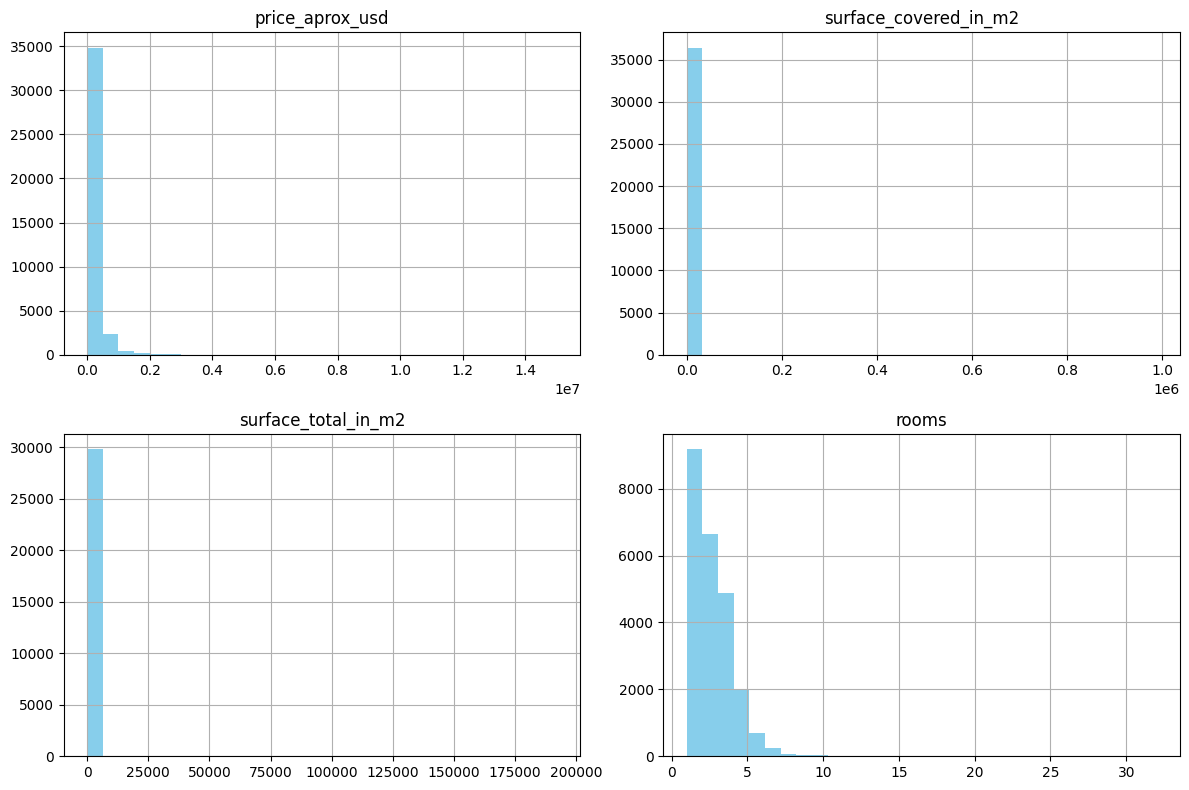

In [8]:
numeric_cols = ["price_aprox_usd", "surface_covered_in_m2", "surface_total_in_m2", "rooms"]
df[numeric_cols].hist(bins=30, figsize=(12,8), color="skyblue")
plt.tight_layout()
plt.show()


# **Checking For Outliers in the data**

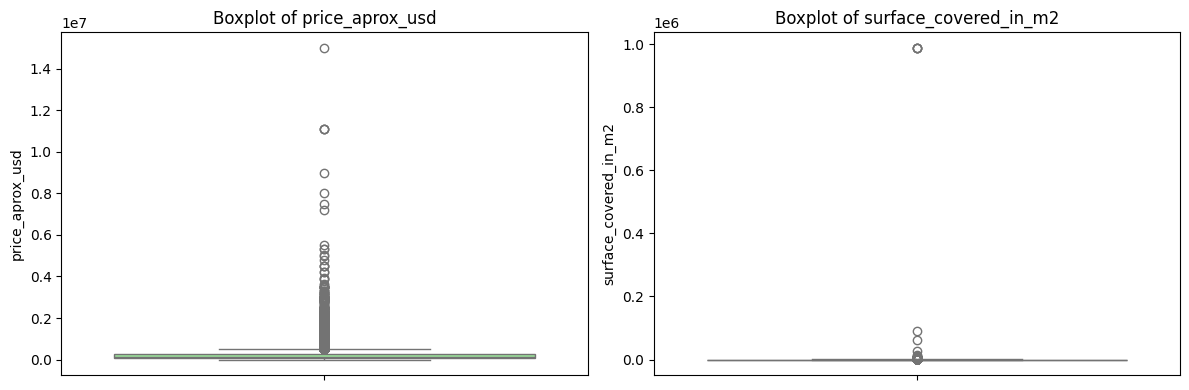

In [9]:
plt.figure(figsize=(12,4))
for i, col in enumerate(["price_aprox_usd", "surface_covered_in_m2"], 1):
    plt.subplot(1,2,i)
    sns.boxplot(y=df[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [10]:
df[numeric_cols].describe()

,price_aprox_usd,surface_covered_in_m2,surface_total_in_m2,rooms
count,3.807300e+04,36420.000000,29871.000000,23806.000000
mean,2.332824e+05,244.493904,269.157578,3.058305
std,3.153684e+05,10371.179349,1686.328201,1.412714
min,0.000000e+00,0.000000,0.000000,1.000000
25%,9.000000e+04,46.000000,47.000000,2.000000
50%,1.450000e+05,76.000000,90.000000,3.000000
75%,2.600000e+05,160.000000,248.000000,4.000000
max,1.500000e+07,987897.000000,192014.000000,32.000000


In [11]:
# lots of nulls here, worth checking before deciding what to drop vs impute
df.isnull().sum()

operation                         0
property_type                     0
place_with_parent_names           0
lat-lon                        8295
price                          4956
currency                       4957
price_aprox_local_currency     4956
price_aprox_usd                4956
surface_total_in_m2           13158
surface_covered_in_m2          6609
price_usd_per_m2              18580
price_per_m2                  10387
floor                         36524
rooms                         19223
expenses                       9180
properati_url                     0
dtype: int64

# **Cleaning columns / feature engineering**

In [12]:
# location string: |Argentina|Capital Federal|Chacarita| -- neighborhood is the 3rd chunk
df["place_with_parent_names"].head()

0             |Argentina|Capital Federal|Villa Crespo|
1    |Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...
2    |Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...
3    |Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...
4                |Argentina|Capital Federal|Chacarita|
Name: place_with_parent_names, dtype: str

In [13]:
# testing cleaning steps loose before wrapping into a function
df_test = df.copy()

df_test = df_test[df_test["property_type"] == "apartment"]
df_test = df_test[df_test["place_with_parent_names"].str.contains("Capital Federal")]
df_test = df_test[df_test["currency"] == "USD"]
df_test = df_test[df_test["price_aprox_usd"] < 400_000]  # cutting off the ultra-luxury tail

low, high = df_test["surface_covered_in_m2"].quantile([0.1, 0.9])
df_test = df_test[df_test["surface_covered_in_m2"].between(low, high)]

df_test.shape

(6146, 16)

In [14]:
# good, wrap it into a wrangle function so every csv gets the same treatment
def wrangle(filepath):
    df = pd.read_csv(filepath)

    df = df[df["property_type"] == "apartment"]
    df = df[df["place_with_parent_names"].str.contains("Capital Federal")]
    df = df[df["currency"] == "USD"]
    df = df[df["price_aprox_usd"] < 400_000]

    # trim size outliers (top/bottom 10%)
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    df = df[df["surface_covered_in_m2"].between(low, high)]

    # split lat-lon into 2 numeric columns -- keeping the nulls here on purpose,
    # planning to impute them later instead of dropping rows
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # neighborhood is always the 3rd chunk of the pipe-separated location string
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    # drop mostly-empty columns, id-like columns, and anything that leaks price
    df.drop(columns=[
        "operation", "property_type", "currency", "properati_url",
        "price", "price_aprox_local_currency",
        "price_usd_per_m2", "price_per_m2",
        "floor", "rooms", "expenses", "surface_total_in_m2",
    ], inplace=True)

    return df


In [15]:
frame = [wrangle(f) for f in files]
df = pd.concat(frame, ignore_index=True)
df.head()

/tmp/ipykernel_498/1178908341.py:3: DtypeWarning: Columns (0: expenses) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,Constitución
4,90000.0,50.0,-34.610610,-58.412511,Once


In [16]:
df.shape

(6146, 5)

In [17]:
# lat/lon still has some nulls -- that's fine, going to impute rather than drop
df.isnull().sum()

price_aprox_usd            0
surface_covered_in_m2      0
lat                      248
lon                      248
neighborhood               0
dtype: int64

In [18]:
df["neighborhood"].nunique()

57

In [19]:
df["neighborhood"].value_counts().head(10)

neighborhood
Palermo          650
Belgrano         525
Caballito        460
Villa Crespo     385
Villa Urquiza    361
Almagro          328
Flores           269
Nuñez            234
Balvanera        216
Barrio Norte     191
Name: count, dtype: int64

# **Explore**

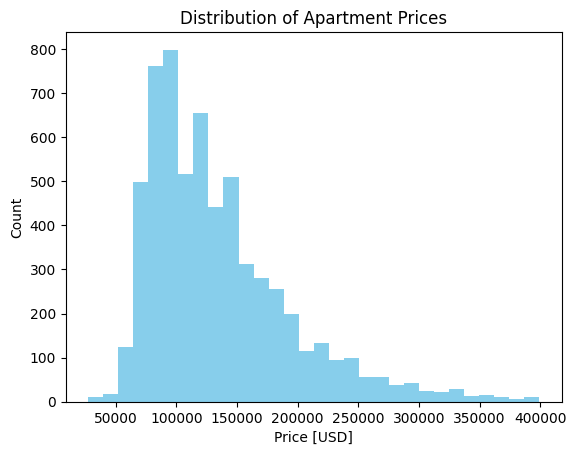

In [20]:
plt.hist(df["price_aprox_usd"], bins=30, color="skyblue")
plt.xlabel("Price [USD]")
plt.ylabel("Count")
plt.title("Distribution of Apartment Prices")
plt.savefig("../images/price_distribution.png", dpi=150)
plt.show()


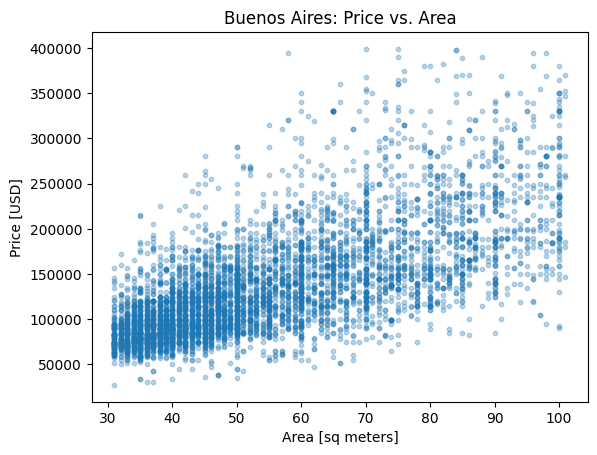

In [21]:
plt.scatter(df["surface_covered_in_m2"], df["price_aprox_usd"], alpha=0.3, s=10)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.savefig("../images/price_vs_area.png", dpi=150)
plt.show()


**Price vs area:** relationship looks similar in shape to Mexico City -- positive but
noisy, plenty of scatter around the trend. Bigger doesn't automatically mean a lot more expensive.

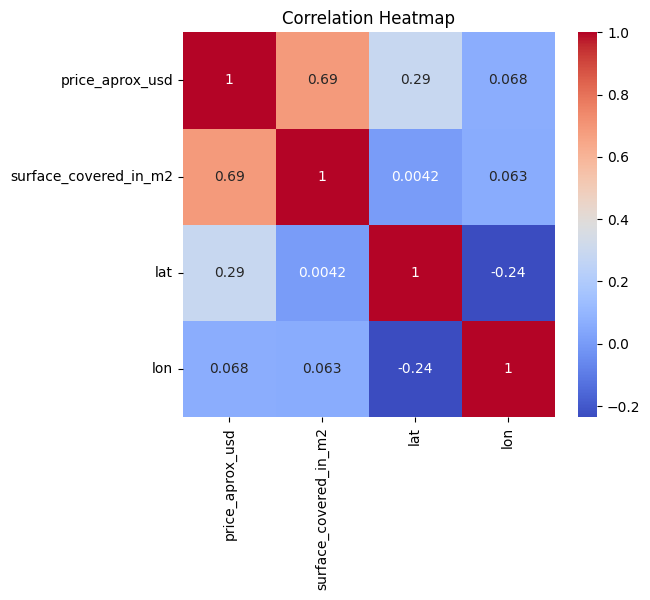

In [22]:
corr = df[["price_aprox_usd", "surface_covered_in_m2", "lat", "lon"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png", dpi=150)
plt.show()


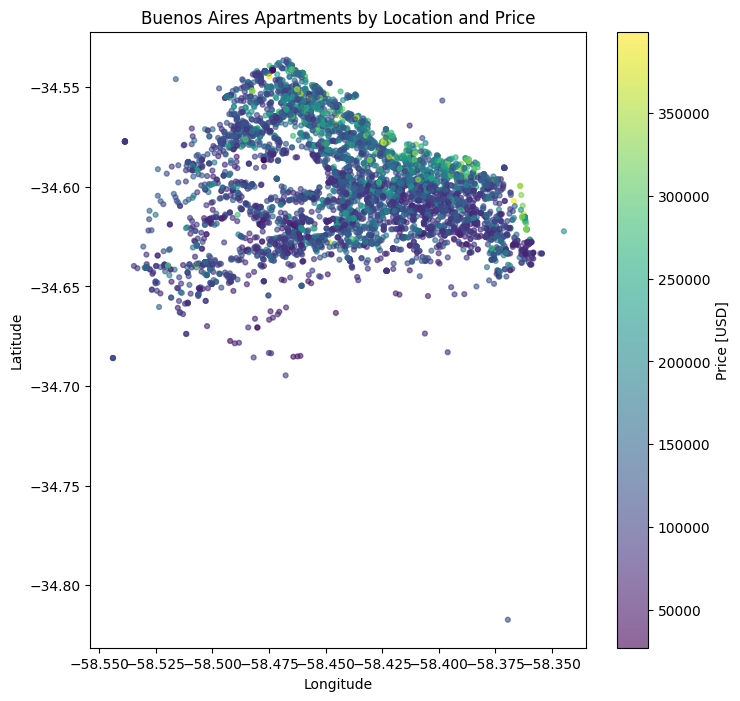

In [23]:
# geographic scatter, color = price -- basically a poor man's Mapbox plot
plt.figure(figsize=(8,8))
sc = plt.scatter(df["lon"], df["lat"], c=df["price_aprox_usd"], cmap="viridis", s=12, alpha=0.6)
plt.colorbar(sc, label="Price [USD]")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Buenos Aires Apartments by Location and Price")
plt.savefig("../images/price_map.png", dpi=150)
plt.show()


Prices aren't spread randomly across the map -- there's visible clustering of pricier
listings in certain pockets (Palermo / Belgrano area looks brighter). Location is probably
worth something to the model, on top of size.

In [24]:
# saving the cleaned data so the model notebooks don't have to repeat all this cleaning
df.to_csv("../data/buenos-aires-cleaned.csv", index=False)
df.shape

(6146, 5)